In [1]:
from astropy.io import fits
import matplotlib.pyplot as plt
from astropy.wcs import WCS
from astropy.table import Table
from matplotlib.patches import Ellipse
from matplotlib.patches import Circle
import os
import matplotlib.cm as cm
from matplotlib.colors import Normalize
import numpy as np
import lenstool
from lenstool.potentials import sis
lenstool.__version__

'8.10.1'

In [47]:

# ORIGINAL CLUSTER (z = 0.27)

ra = np.array([180.1711571,180.1706384,180.1670402,180.1669367,180.1649901,
               180.1647511,180.1620085,180.1585672,180.1578159,180.1571312,180.1547416]) 

dec = np.array([-1.448282774,-1.45269478,-1.452993158,-1.451199272,-1.449266441,
                -1.460621377,-1.446011697,-1.447444124,-1.451612291,-1.452994629,-1.446817617]) 

ra_med = np.median(ra)
dec_med = np.median(dec)

dist = np.sqrt((ra - ra_med)**2 + (dec - dec_med)**2)
central_idx = np.argmin(dist)

ra0 = ra[central_idx]
dec0 = dec[central_idx]

x_arcsec = (ra - ra0) * 3600 * np.cos(np.deg2rad(dec0))
y_arcsec = (dec - dec0) * 3600


lt = lenstool.Lenstool()

# Add first population (z = 0.27)
for i, (xi, yi) in enumerate(zip(x_arcsec, y_arcsec)):

    if i == central_idx:
        sigma = 900
    else:
        sigma = 300

    lt.add_lens(sis(xi, yi, 0.27, sigma))



# SECOND CLUSTER (z = 0.33)

ra2 = np.array([180.1666591,180.1646906,180.1642845,180.1622249,180.1617416,
                180.1606675,180.1596172,180.1569553,180.156192,180.1552601,180.1523198])

dec2 = np.array([-1.444698257,-1.458333486,-1.451220042,-1.452360391,-1.459161248,
                 -1.450250785,-1.451336273,-1.450072663,-1.451267921,-1.452115411,-1.457904632])


dist2 = np.sqrt((ra2 - ra0)**2 + (dec2 - dec0)**2)
central_idx2 = np.argmin(dist2)

# IMPORTANT: use SAME reference (ra0, dec0)
x2_arcsec = (ra2 - ra0) * 3600 * np.cos(np.deg2rad(dec0))
y2_arcsec = (dec2 - dec0) * 3600


# Add second population (z = 0.33)
for i, (xi, yi) in enumerate(zip(x2_arcsec, y2_arcsec)):

    if i == central_idx2:
        sigma = 400
    else:
        sigma = 300

    lt.add_lens(sis(xi, yi, 0.33, sigma))



# LENSTOOL SETTINGS

lt.set_cosmology(73.5, 0.3, 0.7, -1)
lt.set_field(48)
lt.set_grid(2000, 1)

lt.get_lenses()

type,n,x,y,z
int64,str1,float64,float64,float64
1,1,22.194098100700547,3.541201200000277,0.27
1,1,20.327375434156643,-12.342020400000209,0.27
1,1,7.377999110786642,-13.416181199999766,0.27
1,1,7.0055183011046545,-6.958191599999886,0.27
1,1,0.0,0.0,0.27
1,1,-0.8601247683756806,-40.877769600000136,0.27
1,1,-10.7303263981291,11.717078399999714,0.27
1,1,-23.115043407156982,6.560341200000064,0.27
1,1,-25.818858212233312,-8.445059999999938,0.27


In [48]:
tab = Table(names=['n','x','y','a','b','theta','z','mag'], dtype=['str',*['float',]*7]) #n is ID
tab.add_row(['Source 1', 3, -4, 1, 1, 0, 1.4, 20]) #a & b are semi-major axes. If a=b, circle. 
tab.meta['iref'], tab.meta['ref_ra'], tab.meta['ref_dec'] = 3, 0, 0
lt.set_sources(tab)
lt.get_sources()

n,x,y,a,b,theta,z,mag
str8,float64,float64,float64,float64,float64,float64,float64
Source 1,3.0,-4.0,1.0,1.0,0.0,1.4,20.0


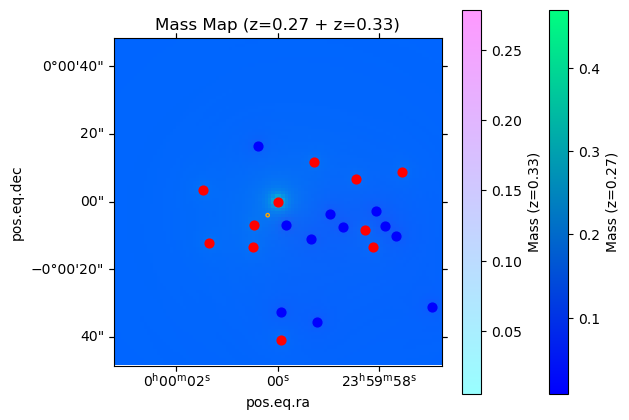

In [49]:
# Compute both mass maps
mass_027, wcs = lt.g_mass(3, 100, 0.27, 1.4)
mass_033, _   = lt.g_mass(3, 100, 0.33, 1.4)

# Plot
fig = plt.figure()
ax = fig.add_axes([0.15, 0.1, 0.8, 0.8], projection=wcs)

# First cluster
im1 = ax.imshow(np.fliplr(mass_027), origin='lower', cmap='winter', alpha=1)

# Second cluster
im2 = ax.imshow(np.fliplr(mass_033), origin='lower', cmap='cool', alpha=0.4)

plt.colorbar(im1, ax=ax, label="Mass (z=0.27)")
plt.colorbar(im2, ax=ax, label="Mass (z=0.33)")

# OPTIONAL: plot galaxy positions

ax.scatter(x_arcsec/3600, y_arcsec/3600,
            transform=ax.get_transform('world'),
            c='red', s=40, label='z=0.27')

ax.scatter(x2_arcsec/3600, y2_arcsec/3600,
            transform=ax.get_transform('world'),
            c='blue', s=40, label='z=0.33')

# Plot sources
for row in lt.get_sources():
    ellipse = Ellipse(
        (row['x']/3600., row['y']/3600.),
        width=row['b']/3600,
        height=row['a']/3600,
        edgecolor='orange',
        facecolor='none',
        angle=row['theta'] + 90,
        transform=ax.get_transform('world')
    )
    ax.add_patch(ellipse)

ax.set_title("Mass Map (z=0.27 + z=0.33)")
plt.show()


In [50]:
lt.e_lensing()
lt.get_images()

n,x,y,a,b,theta,z,mag
str8,float64,float64,float64,float64,float64,float64,float64
Source 1,-26.461542996840222,-9.347881185465775,1.0397016612200312,1.000000000016146,104.8370966519326,1.4,19.957728155277547
Source 1,-36.148450201663344,-9.208852473111552,1.0332545963352526,1.0000000000112237,102.32748515304755,1.4,19.96448163529799
Source 1,-43.0624034933116,-11.893115144303103,1.0295084757082853,1.0000000000130447,103.30692896610641,1.4,19.968425183945573
Source 1,-47.698195411182134,-13.089852299196473,1.027488325071232,1.0000000000131948,103.38476368517917,1.4,19.970557760320872


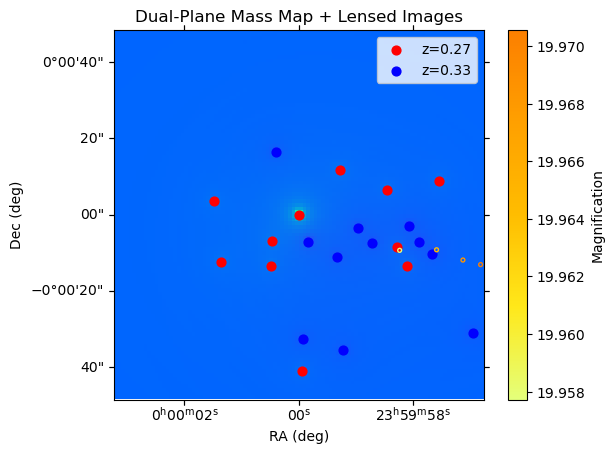

In [51]:
import matplotlib.cm as cm
from matplotlib.colors import Normalize
from matplotlib.patches import Ellipse

def plot_images():

  
    # Get images safely

    images = lt.get_images()

    if len(images) == 0:
        print("No lensed images found.")
        return

    # MASS MAPS (both planes)

    mass_027, wcs = lt.g_mass(3, 100, 0.27, 1.4)
    mass_033, _   = lt.g_mass(3, 100, 0.33, 1.4)

    fig = plt.figure()
    ax = fig.add_subplot(111, projection=wcs)

    # overlay both clusters
    ax.imshow(np.fliplr(mass_027), origin='lower', cmap='winter', alpha=1.0)
    ax.imshow(np.fliplr(mass_033), origin='lower', cmap='cool', alpha=0.4)
    

    # OPTIONAL: plot galaxy positions

    ax.scatter(x_arcsec/3600, y_arcsec/3600,
               transform=ax.get_transform('world'),
               c='red', s=40, label='z=0.27')

    ax.scatter(x2_arcsec/3600, y2_arcsec/3600,
               transform=ax.get_transform('world'),
               c='blue', s=40, label='z=0.33')


    # MAGNIFICATION COLOUR MAP

    norm = Normalize(
        np.min(images['mag']),
        np.max(images['mag'])
    )

    sm = cm.ScalarMappable(norm=norm, cmap='Wistia')
    sm.set_array(images['mag'])

    # PLOT LENSED IMAGES
    for row in images:

        ellipse = Ellipse(
            (row['x'] / 3600, row['y'] / 3600),
            width=row['b'] / 3600,
            height=row['a'] / 3600,
            angle=row['theta'] + 90,
            facecolor='none',
            transform=ax.get_transform('world')
        )

        colour = cm.Wistia(norm(row['mag']))
        ellipse.set_edgecolor(colour)

        ax.add_patch(ellipse)

    # FORMATTING
    ax.set_title("Dual-Plane Mass Map + Lensed Images")
    ax.set_xlabel("RA (deg)")
    ax.set_ylabel("Dec (deg)")
    ax.legend()

    cbar = plt.colorbar(sm, ax=ax)
    cbar.set_label("Magnification")

    plt.show()


plot_images()
